# 03 — Tabu Search for Seismic Velocity Picking

Tabu Search explores the same neighborhood as Hill Climbing (perturb
one pick at a time), but instead of only accepting improving moves, it
accepts the **best non-tabu neighbor even if it is worse** than the
current solution. A short-term memory (the tabu list) forbids undoing
recent moves for a number of iterations, which is what lets the search
escape local optima **without restarting** from a new random solution.

In this context:
- **Solution**: a set of (time, velocity) pairs along a CDP (same as
  Hill Climbing / Random Search)
- **Move**: perturb one pick's time and/or velocity (same operator as
  Hill Climbing — `BaseOptimizer._generate_neighbor`)
- **Tabu attribute**: `(pick_index, time_sample)` — forbids moving a
  pick's time back to a value it just left, for `tabu_tenure`
  iterations
- **Aspiration**: a tabu move is allowed anyway if it beats the best
  score found so far

This is a **visual sanity check only** — one run, CDP 6800 (the same
column used in Coursework 1), formulation v2 constraints. The full
statistical protocol (paired seeds, Wilcoxon test) comes later, once
this first pass confirms the algorithm behaves sensibly.

**Execution order:**
1. Setup
2. Parameters
3. Generate synthetic CDP gather
4. Compute and visualize semblance
5. Run Tabu Search
6. Visualize result
7. Metrics
8. Save results
9. Summary


## 1. Setup

In [107]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Project root: {project_root}')


Project root: /home/rafael-garcia/projetos/seismic-velocity-picking


In [108]:
from src.seismic.io        import load_marmousi2_velocity
from src.seismic.synthetic import generate_cdp_gather
from src.seismic.semblance  import compute_semblance
from src.seismic.cases      import water_bottom_time_ms
from src.optimizers.tabu_search import TabuSearch

print('All modules imported successfully.')


All modules imported successfully.


## 2. Parameters

In [109]:
# --- Acquisition parameters (same as 01_hill_climbing) ---
CDP_IDX      = 6800          # same column used in the Coursework 1 experiments
N_OFFSETS    = 50            # number of receivers
OFFSET_MIN_M = 100.0         # minimum offset in meters
OFFSET_MAX_M = 3000.0        # maximum offset in meters
DT_MS        = 2.0           # time sampling in ms
T_MAX_MS     = 3000.0        # max record time in ms
F0_HZ        = 30.0          # Ricker wavelet frequency
NOISE_LEVEL  = 0.05          # Gaussian noise amplitude

# --- Semblance parameters ---
VEL_MIN      = 1400.0        # min velocity for semblance scan (m/s)
VEL_MAX      = 3000.0        # max velocity for semblance scan (m/s)
VEL_STEP     = 30.0          # velocity increment (m/s)

# --- Formulation v2 constraints (same as the Coursework 1 report) ---
N_PICKS       = 10            # number of picks to find
MIN_SEP_MS    = 100.0        # minimum time separation between picks
T_MAX_PICK_MS = 2700.0       # excludes the far-offset tail of the record
# t_min_ms is "auto": the water-bottom time of THIS column, computed
# below from its own velocity profile.

# --- Tabu Search parameters ---
MAX_EVALS    = 100000        # evaluation budget (within the 1e5–1e6 range
                              # used in the literature) — the ONLY stopping
                              # criterion in this setup
N_NEIGHBORS  = 30            # neighbors evaluated per iteration
MAX_ITER     = 2 * MAX_EVALS // N_NEIGHBORS
                              # upper bound only: generous enough that the
                              # budget is always reached first, even with
                              # invalid neighbors being skipped
PATIENCE     = MAX_ITER      # effectively disables early stopping, so
                              # every run uses exactly MAX_EVALS evaluations
STEP_TIME    = 5             # max time perturbation (samples)
STEP_VEL     = 50.0          # max velocity perturbation (m/s)
TABU_TENURE  = 15            # iterations a forbidden (pick, time) stays tabu
SEED         = 42

print('Parameters set.')


Parameters set.


## 3. Generate synthetic CDP gather

In [110]:
MARMOUSI_DIR = os.path.join(project_root, 'data', 'models', 'marmousi2')

vel_model, info = load_marmousi2_velocity(MARMOUSI_DIR, verbose=False)

vel_profile = vel_model[CDP_IDX, :]
offsets_m   = np.linspace(OFFSET_MIN_M, OFFSET_MAX_M,
                          N_OFFSETS, dtype=np.float32)

gather, t_grid, v_rms_true = generate_cdp_gather(
    vel_profile,
    spacing_m   = info['spacing_m'],
    offsets_m   = offsets_m,
    dt_ms       = DT_MS,
    t_max_ms    = T_MAX_MS,
    f0_hz       = F0_HZ,
    noise_level = NOISE_LEVEL,
    seed        = SEED
)
T_MIN_MS = water_bottom_time_ms(vel_profile, info['spacing_m'])

print(f'Gather shape  : {gather.shape}')
print(f'T max         : {t_grid[-1]:.1f} ms')
print(f'Water bottom  : {T_MIN_MS:.1f} ms')
print(f'V RMS range   : {v_rms_true.min():.1f} - {v_rms_true.max():.1f} m/s')


Gather shape  : (50, 1501)
T max         : 3000.0 ms
Water bottom  : 601.7 ms
V RMS range   : 1500.0 - 2510.8 m/s


## 4. Compute semblance

In [111]:
velocities = np.arange(VEL_MIN, VEL_MAX + VEL_STEP,
                       VEL_STEP, dtype=np.float32)

print('Computing semblance...')
semblance = compute_semblance(gather, offsets_m, velocities, dt_ms=DT_MS)
print(f'Semblance shape: {semblance.shape}  (n_vel x n_samples)')
print(f'Max semblance  : {semblance.max():.4f}')


Computing semblance...
Semblance shape: (55, 1501)  (n_vel x n_samples)
Max semblance  : 0.9855


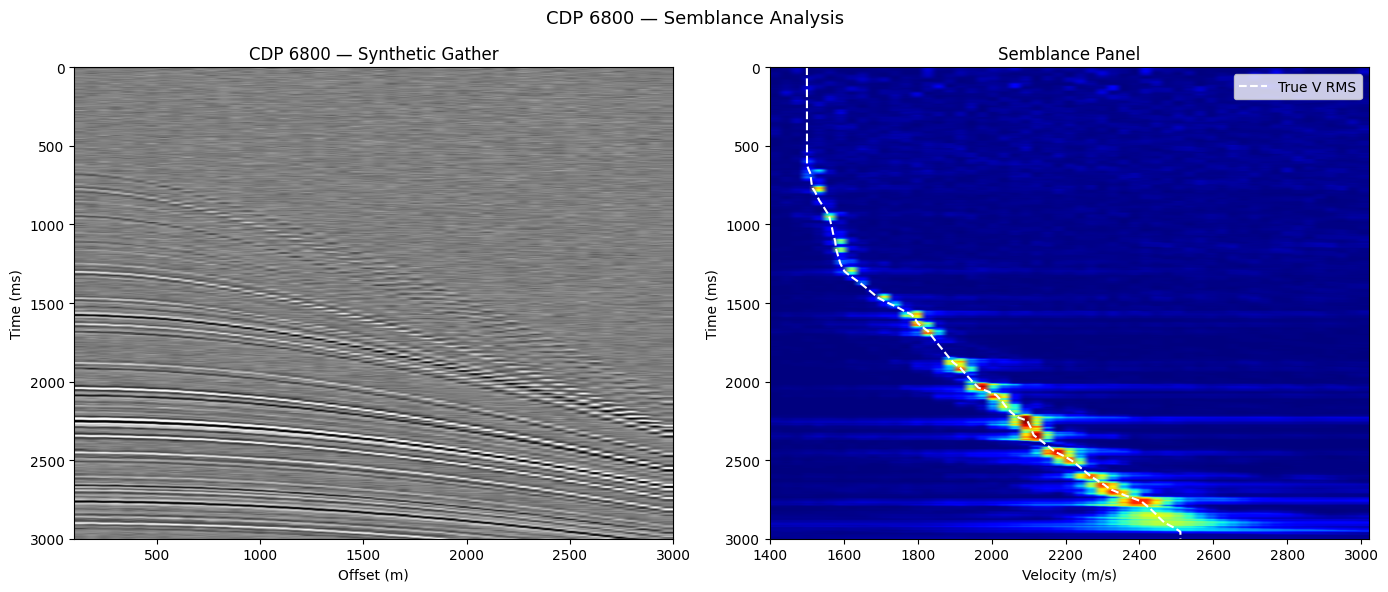

Figure saved.


In [112]:
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmax = np.percentile(np.abs(gather), 98)
axes[0].imshow(
    gather.T, aspect='auto', cmap='gray',
    vmin=-vmax, vmax=vmax,
    extent=[offsets_m[0], offsets_m[-1], t_grid[-1], t_grid[0]]
)
axes[0].set_xlabel('Offset (m)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title(f'CDP {CDP_IDX} — Synthetic Gather')

axes[1].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocities[0], velocities[-1], t_grid[-1], t_grid[0]]
)
axes[1].plot(v_rms_true, t_grid, 'w--', linewidth=1.5, label='True V RMS')
axes[1].set_xlabel('Velocity (m/s)')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Semblance Panel')
axes[1].legend()

plt.suptitle(f'CDP {CDP_IDX} — Semblance Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_semblance_before_picking.png'), dpi=150
)
plt.show()
print('Figure saved.')


## 5. Run Tabu Search

In [113]:
ts = TabuSearch(
    traces      = gather,
    offsets     = offsets_m,
    dt_ms       = DT_MS,
    vel_min     = VEL_MIN,
    vel_max     = VEL_MAX,
    n_picks     = N_PICKS,
    max_iter    = MAX_ITER,
    seed        = SEED,
    step_time   = STEP_TIME,
    step_vel    = STEP_VEL,
    n_neighbors = N_NEIGHBORS,
    tabu_tenure = TABU_TENURE,
    patience    = PATIENCE,
    max_evals   = MAX_EVALS,
    min_sep_ms  = MIN_SEP_MS,
    t_min_ms    = T_MIN_MS,
    t_max_ms    = T_MAX_PICK_MS,
)

print('Running Tabu Search...')
ts.run()

times_pick, vels_pick = ts.get_result()

print(f'Execution time : {ts.exec_time_s:.2f} s')
print(f'Evaluations    : {ts.n_evals}')
print(f'Iterations run : {len(ts.history)} / {MAX_ITER}')
print(f'Best score     : {ts.best_score:.4f}')
print()
print('Picks found (time_ms, velocity_m/s):')
for t, v in zip(times_pick * DT_MS, vels_pick):
    print(f'  t={t:7.1f} ms   v={v:.1f} m/s')


Running Tabu Search...
Execution time : 75.85 s
Evaluations    : 100000
Iterations run : 5803 / 6666
Best score     : 0.5487

Picks found (time_ms, velocity_m/s):
  t=  668.0 ms   v=1506.5 m/s
  t=  768.0 ms   v=1518.6 m/s
  t=  932.0 ms   v=1880.0 m/s
  t= 1110.0 ms   v=1896.1 m/s
  t= 1464.0 ms   v=1907.4 m/s
  t= 1626.0 ms   v=1918.1 m/s
  t= 2030.0 ms   v=1968.3 m/s
  t= 2224.0 ms   v=2085.6 m/s
  t= 2334.0 ms   v=2114.8 m/s
  t= 2440.0 ms   v=2172.5 m/s


In [114]:
print(f'Final tabu list size : {len(ts._tabu)}')
print(f'Stopped by           : '
      f'{"budget" if ts.budget_exhausted else "patience" if len(ts.history) < MAX_ITER else "max_iter"}')

Final tabu list size : 346
Stopped by           : budget


## 6. Visualize result

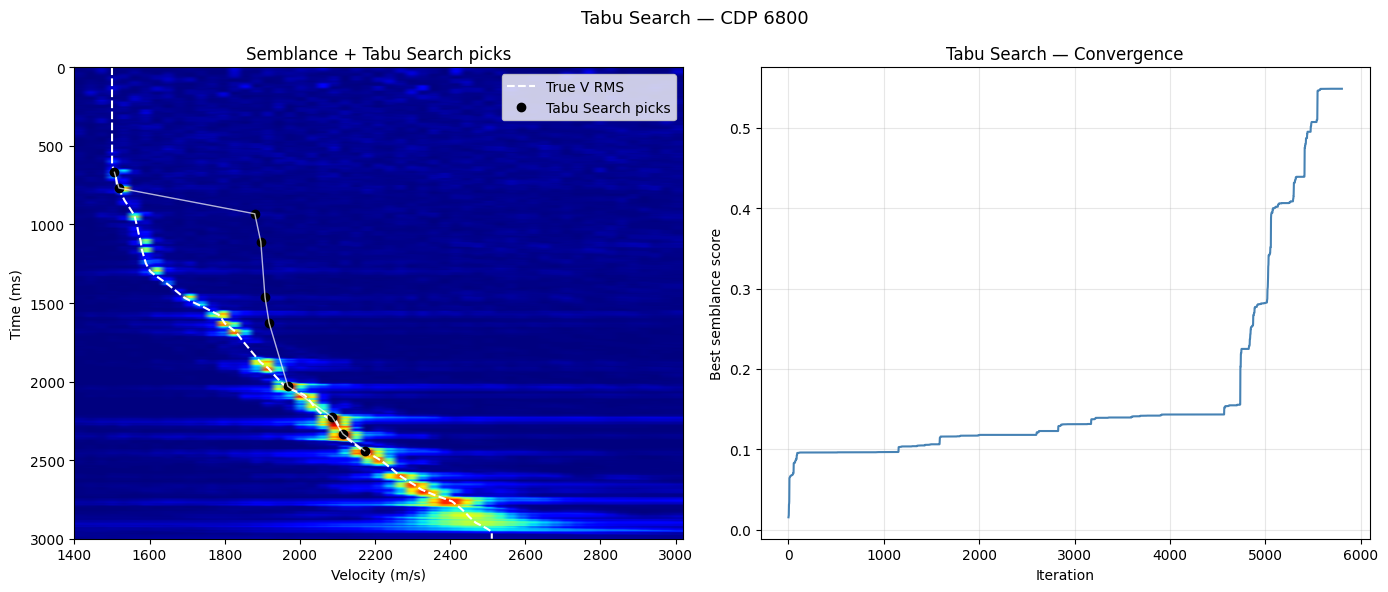

Figure saved.


In [115]:
times_ms = times_pick * DT_MS

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(
    semblance.T, aspect='auto', cmap='jet',
    vmin=0, vmax=1,
    extent=[velocities[0], velocities[-1], t_grid[-1], t_grid[0]]
)
axes[0].plot(v_rms_true, t_grid,
             'w--', linewidth=1.5, label='True V RMS')
axes[0].plot(vels_pick, times_ms,
             'ko', markersize=6, label='Tabu Search picks')
axes[0].plot(vels_pick, times_ms,
             'w-', linewidth=1.0, alpha=0.7)
axes[0].set_xlabel('Velocity (m/s)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Semblance + Tabu Search picks')
axes[0].legend()

axes[1].plot(ts.history, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best semblance score')
axes[1].set_title('Tabu Search — Convergence')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Tabu Search — CDP {CDP_IDX}', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(project_root, 'results', 'figures',
                 '03_tabu_search_result.png'), dpi=150
)
plt.show()
print('Figure saved.')


## 7. Metrics

In [116]:
v_true_at_picks = np.interp(times_ms, t_grid, v_rms_true)

rmse = np.sqrt(np.mean((vels_pick - v_true_at_picks) ** 2))
mae  = np.mean(np.abs(vels_pick - v_true_at_picks))
mape = np.mean(np.abs((vels_pick - v_true_at_picks) / v_true_at_picks)) * 100

print('=== Metrics ===')
print(f'RMSE : {rmse:.2f} m/s')
print(f'MAE  : {mae:.2f} m/s')
print(f'MAPE : {mape:.2f} %')
print(f'Time : {ts.exec_time_s:.2f} s')
print(f'Score: {ts.best_score:.4f}')

print()
print(f'{"Time (ms)":>12} {"Picked (m/s)":>14} {"True (m/s)":>12} {"Error (m/s)":>12}')
print('-' * 54)
for t, vp, vt in zip(times_ms, vels_pick, v_true_at_picks):
    err = vp - vt
    print(f'{t:12.1f} {vp:14.1f} {vt:12.1f} {err:+12.1f}')


=== Metrics ===
RMSE : 163.55 m/s
MAE  : 101.22 m/s
MAPE : 6.22 %
Time : 75.85 s
Score: 0.5487

   Time (ms)   Picked (m/s)   True (m/s)  Error (m/s)
------------------------------------------------------
       668.0         1506.5       1508.0         -1.5
       768.0         1518.6       1515.5         +3.1
       932.0         1880.0       1557.0       +323.0
      1110.0         1896.1       1576.7       +319.4
      1464.0         1907.4       1691.3       +216.1
      1626.0         1918.1       1799.4       +118.8
      2030.0         1968.3       1960.4         +7.9
      2224.0         2085.6       2069.7        +15.9
      2334.0         2114.8       2112.5         +2.4
      2440.0         2172.5       2168.3         +4.2


## 8. Save results

In [117]:
os.makedirs(os.path.join(project_root, 'results', 'metrics'), exist_ok=True)
os.makedirs(os.path.join(project_root, 'results', 'picks'),   exist_ok=True)

metrics = {
    'algorithm':    'TabuSearch',
    'cdp':          CDP_IDX,
    'rmse':         float(rmse),
    'mae':          float(mae),
    'mape':         float(mape),
    'best_score':   float(ts.best_score),
    'exec_time_s':  float(ts.exec_time_s),
    'n_evals':      ts.n_evals,
    'n_picks':      N_PICKS,
    'max_iter':     MAX_ITER,
    'iters_run':    len(ts.history),
    'tabu_tenure':  TABU_TENURE,
    'patience':     PATIENCE,
    'seed':         SEED,
}

metrics_path = os.path.join(project_root, 'results', 'metrics',
                            'tabu_search.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

picks_path = os.path.join(project_root, 'results', 'picks',
                          'tabu_search.npy')
np.save(picks_path, {
    'times_ms':  times_ms,
    'vels_pick': vels_pick,
    'v_true':    v_true_at_picks,
})

history_path = os.path.join(project_root, 'results', 'metrics',
                            'tabu_search_history.npy')
np.save(history_path, np.array(ts.history))

print('Results saved:')
print(f'  Metrics : {metrics_path}')
print(f'  Picks   : {picks_path}')
print(f'  History : {history_path}')
print()
print(json.dumps(metrics, indent=2))


Results saved:
  Metrics : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/tabu_search.json
  Picks   : /home/rafael-garcia/projetos/seismic-velocity-picking/results/picks/tabu_search.npy
  History : /home/rafael-garcia/projetos/seismic-velocity-picking/results/metrics/tabu_search_history.npy

{
  "algorithm": "TabuSearch",
  "cdp": 6800,
  "rmse": 163.55100101841631,
  "mae": 101.22478727885152,
  "mape": 6.216205417891772,
  "best_score": 0.5486858559772372,
  "exec_time_s": 75.84515396300048,
  "n_evals": 100000,
  "n_picks": 10,
  "max_iter": 6666,
  "iters_run": 5803,
  "tabu_tenure": 15,
  "patience": 6666,
  "seed": 42
}


## 9. Summary

This is a **single-run visual check** of Tabu Search on the main case
(CDP 6800), with the same per-run budget as the Coursework 1 report
— the goal is only to confirm the algorithm behaves sensibly (finds a
reasonable set of picks, the tabu list gets populated and used, it
does not stall) before moving on to a more robust evaluation.

**What this notebook does NOT do yet:**
- No comparison against Hill Climbing or Random Search — Coursework 2
  is focused on Tabu Search (and, later, a Tabu Search + Simulated
  Annealing hybrid), not on repeating the Coursework 1 comparisons.
- No statistical protocol (paired seeds across multiple runs, Wilcoxon
  test) — that is the next step once this visual check looks right.

**Next steps:**
- A more robust evaluation (multiple seeds, convergence behavior
  across runs) before writing up Coursework 2.
- A future `TabuSearchSA` — a Tabu Search + Simulated Annealing hybrid
  (probabilistic acceptance of non-tabu worsening moves, with a
  cooling schedule), discussed conceptually but not implemented yet.
